1. Bibliotheques pretes.
2. Donnees nettoyees.

3. --- STATISTIQUES ---
Accidents : 500
Deces : 37432
Survie moyenne : 50.03%
   Decade  Nombre_Accidents  Total_Deces  Taux_Survie_Moyen
0    1950                68         5605           0.521020
1    1960                67         5550           0.448884
2    1970                68         4768           0.552344
3    1980                67         5688           0.469429
4    1990                68         4604           0.495630
5    2000                67         4657           0.502120
6    2010                68         5118           0.463783
7    2020                27         1442           0.621279

4. --- TEST STATISTIQUE ---
Statistique T : -0.4463
P-value : 0.65607
Resultat : Pas de difference significative.

5. Generation des graphiques...


/tmp/ipykernel_2329/75503851.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Region', ax=axes[1], order=ordre_regions, palette='viridis')


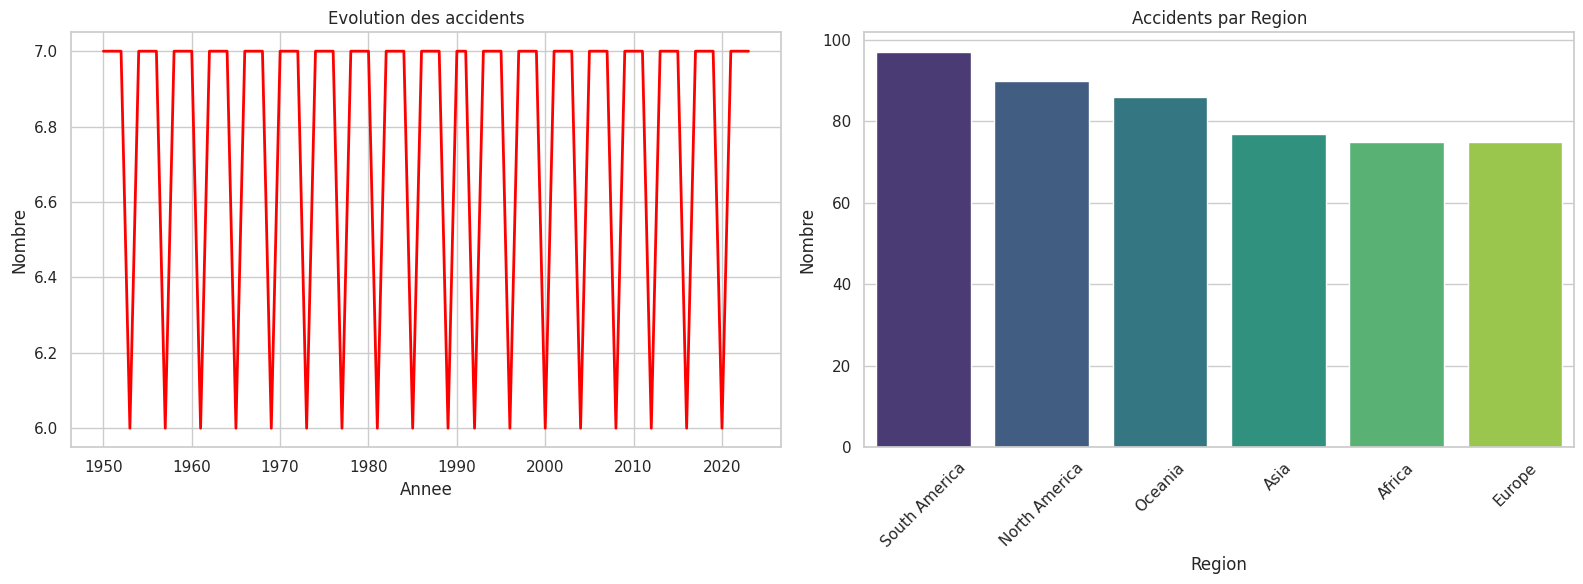

--- FIN DU SCRIPT ---


In [27]:
# =====================================================================
# DEFI QUOTIDIEN : ANALYSE DES ACCIDENTS D'AVION (VERSION SECURISEE)
# =====================================================================

# --- STEP 1 : LIBRARIERS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("1. Bibliotheques pretes.")


# --- STEP 2 : DATA GENERATION & CLEANING ---
np.random.seed(42)
n_incidents = 500

dates = pd.date_range(start="1950-01-01", end="2023-12-31", periods=n_incidents)
regions = np.random.choice(['North America', 'Europe', 'Asia', 'South America', 'Africa', 'Oceania'], n_incidents)
aboard = np.random.randint(10, 300, n_incidents)
fatalities = np.array([np.random.randint(0, ab + 1) for ab in aboard])

df = pd.DataFrame({
    'Date': dates,
    'Region': regions,
    'Aboard': aboard,
    'Fatalities': fatalities
})

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Decade'] = (df['Year'] // 10) * 10
df['Survival_Rate'] = (df['Aboard'] - df['Fatalities']) / df['Aboard']
df['Fatalities'] = df['Fatalities'].fillna(df['Fatalities'].median())

print("2. Donnees nettoyees.")


# --- STEP 3 : EDA (ANALYSIS) ---
total_accidents = len(df)
total_fatalities = df['Fatalities'].sum()
global_survival_avg = df['Survival_Rate'].mean() * 100

print("\n3. --- STATISTIQUES ---")
print(f"Accidents : {total_accidents}")
print(f"Deces : {total_fatalities}")
print(f"Survie moyenne : {global_survival_avg:.2f}%")

summary_by_decade = df.groupby('Decade').agg(
    Nombre_Accidents=('Date', 'count'),
    Total_Deces=('Fatalities', 'sum'),
    Taux_Survie_Moyen=('Survival_Rate', 'mean')
).reset_index()
print(summary_by_decade)


# --- STEP 4 : SCIPY TESTS ---
print("\n4. --- TEST STATISTIQUE ---")
deces_1970 = df[df['Decade'] == 1970]['Fatalities']
deces_2010 = df[df['Decade'] == 2010]['Fatalities']

t_stat, p_value = stats.ttest_ind(deces_1970, deces_2010, equal_var=False)
print(f"Statistique T : {t_stat:.4f}")
print(f"P-value : {p_value:.5f}")

if p_value < 0.05:
    print("Resultat : Difference significative entre 1970 et 2010.")
else:
    print("Resultat : Pas de difference significative.")


# --- STEP 5 : GRAPHICS ---
print("\n5. Generation des graphiques...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1
data_annee = df.groupby('Year').size().reset_index(name='Count')
sns.lineplot(data=data_annee, x='Year', y='Count', ax=axes[0], color='red', lw=2)
axes[0].set_title("Evolution des accidents")
axes[0].set_xlabel("Annee")
axes[0].set_ylabel("Nombre")

# Graphique 2
ordre_regions = df['Region'].value_counts().index
sns.countplot(data=df, x='Region', ax=axes[1], order=ordre_regions, palette='viridis')
axes[1].set_title("Accidents par Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Nombre")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("--- FIN DU SCRIPT ---")